# Goal:
 - Load processed multimodal sensor features
 - Build a binary quantum classification task: rest vs active
 - Train and evaluate QSVM
 - Compare QSVM with Random Forest and SVM on the same features
 - Save metrics and charts for reporting

## 1) Imports

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

## 2) Qiskit imports

In [13]:
from qiskit.circuit.library import zz_feature_map
from qiskit_aer import AerSimulator
from qiskit_machine_learning.algorithms import QSVC
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit.visualization import circuit_drawer

## 3) Paths

In [39]:
DATA_PATH = Path("../data/processed/activity_fusion_features_sensors_strict.csv")
PLOTS_DIR = Path("../outputs/plots")
LOGS_DIR = Path("../outputs/logs")

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
LOGS_DIR.mkdir(parents=True, exist_ok=True)

print("Loading from:", DATA_PATH.resolve())

Loading from: C:\Users\vPro\OneDrive - Al Akhawayn University in Ifrane\AUI\capstone\capstone\ml_pipeline\data\processed\activity_fusion_features_sensors_strict.csv


## 4) Load dataset

In [15]:
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print(df.columns.tolist())
df.head()

Shape: (366, 45)
['hr_mean', 'hr_std', 'hr_min', 'hr_max', 'hr_range', 'temp_mean', 'temp_std', 'temp_min', 'temp_max', 'temp_slope', 'emg_raw_mean', 'emg_raw_std', 'emg_env_mean', 'emg_env_std', 'emg_rms', 'emg_mav', 'emg_wl', 'emg_zero_cross', 'emg_state_mean', 'ax_mean', 'ax_std', 'ax_min', 'ax_max', 'ay_mean', 'ay_std', 'ay_min', 'ay_max', 'az_mean', 'az_std', 'az_min', 'az_max', 'acc_mag_mean', 'acc_mag_std', 'acc_mag_min', 'acc_mag_max', 'acc_mag_range', 'acc_mag_energy', 'jerk_mean', 'jerk_std', 'label_name', 'label', 'source_file', 'window_start', 'window_end', 'n_samples']


,hr_mean,hr_std,hr_min,hr_max,hr_range,temp_mean,temp_std,temp_min,temp_max,temp_slope,...,acc_mag_range,acc_mag_energy,jerk_mean,jerk_std,label_name,label,source_file,window_start,window_end,n_samples
0,97.300000,2.213594,94.0,101.0,7.0,27.723000,0.102746,27.56,27.87,-0.031000,...,2041.468517,3.373528e+08,614.065686,866.594422,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:17.519406,2026-04-14 19:53:27.519406,10
1,105.900000,2.998148,101.0,109.0,8.0,27.275000,0.224314,26.94,27.56,-0.062000,...,17747.568929,3.820010e+08,11053.029205,11543.581328,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:27.519406,2026-04-14 19:53:37.519406,10
2,107.888889,3.551213,105.0,114.0,9.0,26.582222,0.195114,26.31,26.87,-0.062222,...,21984.351951,5.460429e+08,13962.586061,14692.866503,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:37.519406,2026-04-14 19:53:47.519406,9
3,122.300000,5.375872,114.0,129.0,15.0,25.968000,0.189021,25.69,26.25,-0.056000,...,18848.170897,4.017341e+08,13013.301236,13811.219595,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:47.519406,2026-04-14 19:53:57.519406,10
4,126.900000,0.994429,126.0,129.0,3.0,25.461000,0.139400,25.25,25.69,-0.044000,...,21599.531893,4.433055e+08,11563.092523,13163.102565,intense,2,intense/intense_running_20260414_195242.csv,2026-04-14 19:53:57.519406,2026-04-14 19:54:07.519406,10


## 5) Create binary target: rest vs active

In [22]:
# Rebuild from scratch
df_binary = df.copy()

# Create binary string label
df_binary["binary_label_name"] = np.where(
    df_binary["label_name"] == "rest",
    "rest",
    "active"
)

# Create numeric binary label
df_binary["binary_label"] = np.where(
    df_binary["binary_label_name"] == "rest",
    0,
    1
)

# Split by class manually
rest_df = df_binary[df_binary["binary_label"] == 0].copy()
active_df = df_binary[df_binary["binary_label"] == 1].copy()

# Sample up to 60 from each class
rest_df = rest_df.sample(n=min(len(rest_df), 60), random_state=42)
active_df = active_df.sample(n=min(len(active_df), 60), random_state=42)

# Recombine
df_binary = pd.concat([rest_df, active_df], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

# Check
print(df_binary.columns.tolist())
print(df_binary["binary_label_name"].value_counts())
print(df_binary["binary_label"].value_counts())
print("Shape:", df_binary.shape)
df_binary.head()

['hr_mean', 'hr_std', 'hr_min', 'hr_max', 'hr_range', 'temp_mean', 'temp_std', 'temp_min', 'temp_max', 'temp_slope', 'emg_raw_mean', 'emg_raw_std', 'emg_env_mean', 'emg_env_std', 'emg_rms', 'emg_mav', 'emg_wl', 'emg_zero_cross', 'emg_state_mean', 'ax_mean', 'ax_std', 'ax_min', 'ax_max', 'ay_mean', 'ay_std', 'ay_min', 'ay_max', 'az_mean', 'az_std', 'az_min', 'az_max', 'acc_mag_mean', 'acc_mag_std', 'acc_mag_min', 'acc_mag_max', 'acc_mag_range', 'acc_mag_energy', 'jerk_mean', 'jerk_std', 'label_name', 'label', 'source_file', 'window_start', 'window_end', 'n_samples', 'binary_label_name', 'binary_label']
binary_label_name
rest      60
active    60
Name: count, dtype: int64
binary_label
0    60
1    60
Name: count, dtype: int64
Shape: (120, 47)


,hr_mean,hr_std,hr_min,hr_max,hr_range,temp_mean,temp_std,temp_min,temp_max,temp_slope,...,jerk_mean,jerk_std,label_name,label,source_file,window_start,window_end,n_samples,binary_label_name,binary_label
0,77.100000,0.567646,76.0,78.0,2.0,32.588,0.036148,32.56,32.63,0.007,...,55.537263,75.576173,rest,0,rest/rest_20260417_152340.csv,2026-04-17 15:28:25.185434,2026-04-17 15:28:35.185434,10,rest,0
1,77.400000,1.074968,75.0,78.0,3.0,32.574,0.029515,32.56,32.63,0.000,...,67.926129,69.876725,rest,0,rest/rest_20260417_152340.csv,2026-04-17 15:28:15.185434,2026-04-17 15:28:25.185434,10,rest,0
2,81.300000,2.359378,77.0,83.0,6.0,31.792,0.028983,31.75,31.81,0.006,...,155.845530,240.629025,rest,0,rest/rest_20260417_152340.csv,2026-04-17 15:24:15.185434,2026-04-17 15:24:25.185434,10,rest,0
3,74.000000,1.500000,72.0,76.0,4.0,32.750,0.000000,32.75,32.75,0.000,...,178.889458,210.643480,rest,0,rest/rest_20260417_152938.csv,2026-04-17 15:30:50.996507,2026-04-17 15:31:00.996507,9,rest,0
4,75.666667,0.707107,74.0,76.0,2.0,32.810,0.000000,32.81,32.81,0.000,...,189.412865,201.483017,rest,0,rest/rest_20260417_152938.csv,2026-04-17 15:32:10.996507,2026-04-17 15:32:20.996507,9,rest,0


## 6) Reduced feature set for QSVM

In [23]:
selected_features = [
    "hr_mean",
    "temp_mean",
    "emg_rms",
    "acc_mag_mean",
]

missing = [c for c in selected_features if c not in df_binary.columns]
print("Missing features:", missing)

X = df_binary[selected_features].copy()
y = df_binary["binary_label"].copy()

print("X shape:", X.shape)
print("y distribution:\n", y.value_counts())

Missing features: []
X shape: (120, 4)
y distribution:
 binary_label
0    60
1    60
Name: count, dtype: int64


## 7) Train/test split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (90, 4)
Test shape: (30, 4)


## 8) Scale features

In [25]:
std_scaler = StandardScaler()
minmax_scaler = MinMaxScaler(feature_range=(0, np.pi))

X_train_std = std_scaler.fit_transform(X_train)
X_test_std = std_scaler.transform(X_test)

X_train_q = minmax_scaler.fit_transform(X_train_std)
X_test_q = minmax_scaler.transform(X_test_std)

print("Quantum-scaled train shape:", X_train_q.shape)

Quantum-scaled train shape: (90, 4)


## 9) Visual check of scaled features

In [26]:
pd.DataFrame(X_train_q, columns=selected_features).describe()

,hr_mean,temp_mean,emg_rms,acc_mag_mean
count,90.000000,90.000000,90.000000,90.000000
mean,1.123223,2.556251,0.625182,1.594443
std,1.004178,0.630058,0.685151,0.586401
min,0.000000,0.000000,0.000000,0.000000
25%,0.207772,2.543558,0.233863,1.268205
50%,0.875249,2.752449,0.311015,1.556542
75%,1.748148,2.914755,0.776493,1.614469
max,3.141593,3.141593,3.141593,3.141593


## 10) Build quantum feature map

In [40]:
num_features = len(selected_features)

feature_map = zz_feature_map(
    feature_dimension=num_features,
    reps=1,
    entanglement="linear"
)

print(feature_map)

   ┌───┐┌───────────┐                                               »
0: ┤ H ├┤ P(2*x[0]) ├──■────────────────────────────────────■───────»
   ├───┤├───────────┤┌─┴─┐┌──────────────────────────────┐┌─┴─┐     »
1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P((-π + x[0])*(-π + x[1])*2) ├┤ X ├──■──»
   ├───┤├───────────┤└───┘└──────────────────────────────┘└───┘┌─┴─┐»
2: ┤ H ├┤ P(2*x[2]) ├──────────────────────────────────────────┤ X ├»
   ├───┤├───────────┤                                          └───┘»
3: ┤ H ├┤ P(2*x[3]) ├───────────────────────────────────────────────»
   └───┘└───────────┘                                               »
«                                                                             »
«0: ──────────────────────────────────────────────────────────────────────────»
«                                                                             »
«1: ──────────────────────────────────■───────────────────────────────────────»
«   ┌──────────────────────────────┐┌─┴─┐         

## 11) Build Quantum kernel and QSVM

In [28]:
from qiskit_machine_learning.kernels import FidelityQuantumKernel

quantum_kernel = FidelityQuantumKernel(
    feature_map=feature_map
)

qsvm = QSVC(quantum_kernel=quantum_kernel)

## 12) Train QSVM

In [29]:
qsvm.fit(X_train_q, y_train)
y_pred_qsvm = qsvm.predict(X_test_q)

qsvm_acc = accuracy_score(y_test, y_pred_qsvm)

print("QSVM Accuracy:", qsvm_acc)
print("\nQSVM Classification Report:\n")
print(classification_report(y_test, y_pred_qsvm, target_names=["rest", "active"]))

QSVM Accuracy: 0.9666666666666667

QSVM Classification Report:

              precision    recall  f1-score   support

        rest       0.94      1.00      0.97        15
      active       1.00      0.93      0.97        15

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## 13) QSVM confusion matrix

[[15  0]
 [ 1 14]]


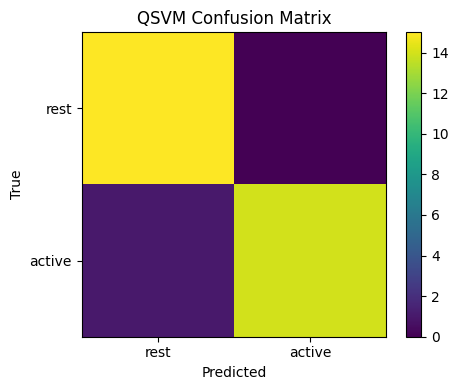

In [30]:
cm_qsvm = confusion_matrix(y_test, y_pred_qsvm)
print(cm_qsvm)

plt.figure(figsize=(5,4))
plt.imshow(cm_qsvm, interpolation="nearest")
plt.title("QSVM Confusion Matrix")
plt.colorbar()
plt.xticks([0,1], ["rest", "active"])
plt.yticks([0,1], ["rest", "active"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "chart_qsvm_confusion_matrix.png", dpi=300)
plt.show()

## 14) Random Forest benchmark on same binary task

In [31]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=8,
    min_samples_leaf=4,
    random_state=42,
    class_weight="balanced"
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)

print("RF Accuracy:", rf_acc)
print("\nRF Classification Report:\n")
print(classification_report(y_test, y_pred_rf, target_names=["rest", "active"]))

RF Accuracy: 0.9666666666666667

RF Classification Report:

              precision    recall  f1-score   support

        rest       0.94      1.00      0.97        15
      active       1.00      0.93      0.97        15

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## 15) SVM benchmark on same binary task

In [32]:
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(
        kernel="rbf",
        C=1.0,
        gamma="scale",
        class_weight="balanced",
        random_state=42
    ))
])

svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

svm_acc = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", svm_acc)
print("\nSVM Classification Report:\n")
print(classification_report(y_test, y_pred_svm, target_names=["rest", "active"]))

SVM Accuracy: 0.9

SVM Classification Report:

              precision    recall  f1-score   support

        rest       0.83      1.00      0.91        15
      active       1.00      0.80      0.89        15

    accuracy                           0.90        30
   macro avg       0.92      0.90      0.90        30
weighted avg       0.92      0.90      0.90        30



## 16) Comparison table

In [33]:
qsvm_report = classification_report(y_test, y_pred_qsvm, target_names=["rest", "active"], output_dict=True)
rf_report = classification_report(y_test, y_pred_rf, target_names=["rest", "active"], output_dict=True)
svm_report = classification_report(y_test, y_pred_svm, target_names=["rest", "active"], output_dict=True)

comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "QSVM": [
        qsvm_acc,
        qsvm_report["macro avg"]["precision"],
        qsvm_report["macro avg"]["recall"],
        qsvm_report["macro avg"]["f1-score"]
    ],
    "Random Forest": [
        rf_acc,
        rf_report["macro avg"]["precision"],
        rf_report["macro avg"]["recall"],
        rf_report["macro avg"]["f1-score"]
    ],
    "SVM": [
        svm_acc,
        svm_report["macro avg"]["precision"],
        svm_report["macro avg"]["recall"],
        svm_report["macro avg"]["f1-score"]
    ]
})

comparison_df

,Metric,QSVM,Random Forest,SVM
0,Accuracy,0.966667,0.966667,0.900000
1,Precision,0.968750,0.968750,0.916667
2,Recall,0.966667,0.966667,0.900000
3,F1-score,0.966630,0.966630,0.898990


## 17) Comparison chart

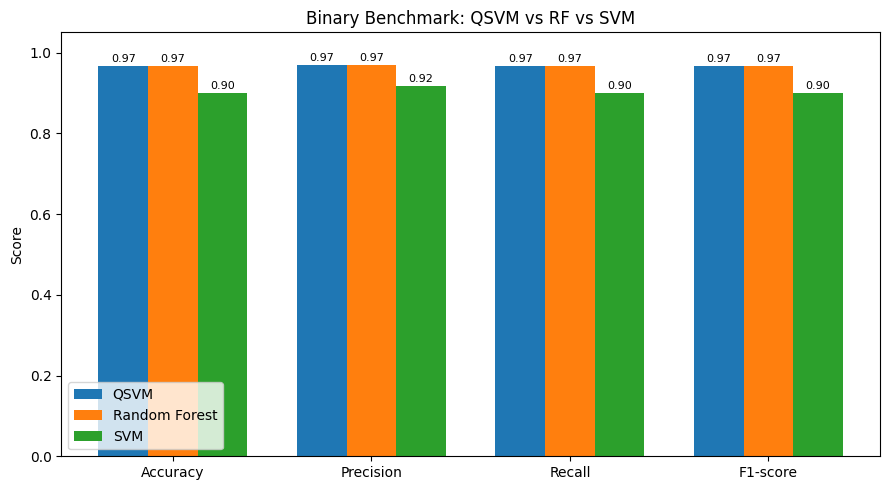

In [35]:
metrics = comparison_df["Metric"]
x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(9,5))
plt.bar(x - width, comparison_df["QSVM"], width, label="QSVM")
plt.bar(x, comparison_df["Random Forest"], width, label="Random Forest")
plt.bar(x + width, comparison_df["SVM"], width, label="SVM")

plt.xticks(x, metrics)
plt.ylim(0, 1.05)
plt.ylabel("Score")
plt.title("Binary Benchmark: QSVM vs RF vs SVM")
plt.legend()

for i, v in enumerate(comparison_df["QSVM"]):
    plt.text(i - width, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)

for i, v in enumerate(comparison_df["Random Forest"]):
    plt.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)

for i, v in enumerate(comparison_df["SVM"]):
    plt.text(i + width, v + 0.01, f"{v:.2f}", ha="center", fontsize=8)

plt.tight_layout()
plt.savefig(PLOTS_DIR / ,"chart_qsvm_rf_svm_comparison.png", dpi=300)
plt.show()

## 18) Save metrics summary text file

In [36]:
with open(LOGS_DIR /, "qsvm_binary_metrics_summary.txt", "w", encoding="utf-8") as f:
    f.write("QSVM Binary Benchmark: Rest vs Active\n")
    f.write("=" * 60)

    f.write("\n\nSelected features:\n")
    f.write(", ".join(selected_features))

    f.write("\n\nQSVM Accuracy:\n")
    f.write(str(qsvm_acc))

    f.write("\n\nQSVM Classification Report:\n")
    f.write(classification_report(y_test, y_pred_qsvm, target_names=["rest", "active"]))

    f.write("\nRandom Forest Accuracy:\n")
    f.write(str(rf_acc))

    f.write("\n\nRandom Forest Classification Report:\n")
    f.write(classification_report(y_test, y_pred_rf, target_names=["rest", "active"]))

    f.write("\nSVM Accuracy:\n")
    f.write(str(svm_acc))

    f.write("\n\nSVM Classification Report:\n")
    f.write(classification_report(y_test, y_pred_svm, target_names=["rest", "active"]))

    f.write("\nComparison Table:\n")
    f.write(comparison_df.to_string(index=False))

print("Saved quantum benchmark summary.")

Saved quantum benchmark summary.


## 19) Save comparison table CSV

In [37]:
comparison_df.to_csv(DATA_PATH /, "qsvm_binary_comparison_table.csv", index=False)
print("Saved comparison table.")

Saved comparison table.


## 20) Save feature map diagram as image

In [ ]:
fig = feature_map.decompose().draw("mpl")
fig.savefig(PLOTS_DIR /, "qsvm_feature_map.png", dpi=300, bbox_inches="tight")
plt.show()

## CONCLUSION

This notebook benchmarks a quantum support vector machine (QSVM) against two classical models,
Random Forest and SVM, on the binary task of distinguishing rest from active states using
engineered multimodal sensor features. A reduced feature subset was selected to keep the
quantum model computationally tractable. The results provide an experimental comparison of
quantum and classical classification on the custom wearable dataset, complementing the main
classical activity-recognition pipeline.